# Churn EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
# Project color palette
COLORS = {
    "primary": "#2A9D8F",      
    "secondary": "#264653",    
    "accent": "#E9C46A",       
    "highlight": "#F4A261",    
    "churn": "#E76F51",        
    "retained": "#2A9D8F"      
}

# General plotting style
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

plt.rcParams.update({
    "figure.figsize": (6, 4),
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 100
})

CHURN_PALETTE = {
    0: "#2A9D8F",  
    1: "#E76F51"   
}

In [13]:
df = pd.read_csv('customer_churn_feature.csv')
df.head(5)

,customer_id,identity_segment,age,income,group_size,location,preferred_price_tier,preferred_rest_type,total_spend,avg_order_value,...,unique_restaurants,unique_cuisines,unique_rest_types,restaurant_loyalty,cuisine_loyalty,avg_actual_group_size,std_group_size,avg_price_deviation,rest_type_match_rate,churned
0,1000001,Couple,43,59373,1,Whitefield,Mid-range,Fine Dining,2052.3801,684.126678,...,3,3,3,0.333333,0.333333,1.0,0.0,223.186676,0.333333,0
1,1000002,Office Worker,36,87255,2,HSR,Budget,Cafe,8202.4990,630.961535,...,13,13,3,0.076923,0.076923,2.0,0.0,297.756919,0.846154,1
2,1000003,Couple,28,102362,3,Koramangala 5th Block,Mid-range,Cafe,14056.7010,669.366669,...,21,17,5,0.047619,0.190476,3.0,0.0,350.020945,0.809524,1
3,1000004,Family,55,178855,7,Indiranagar,Mid-range,Casual Dining,10220.6600,567.814441,...,18,18,3,0.055556,0.055556,7.0,0.0,167.776671,0.833333,1
4,1000005,Student,24,20379,3,Bannerghatta Road,Budget,Beverage Shop,1250.0300,312.507505,...,4,3,3,0.250000,0.500000,3.0,0.0,138.842499,0.500000,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9258 entries, 0 to 9257
Data columns (total 36 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   customer_id            9258 non-null   int64  
 1   identity_segment       9258 non-null   object 
 2   age                    9258 non-null   int64  
 3   income                 9258 non-null   int64  
 4   group_size             9258 non-null   int64  
 5   location               9258 non-null   object 
 6   preferred_price_tier   9258 non-null   object 
 7   preferred_rest_type    9258 non-null   object 
 8   total_spend            9258 non-null   float64
 9   avg_order_value        9258 non-null   float64
 10  median_order_value     9258 non-null   float64
 11  std_order_value        8486 non-null   float64
 12  max_order_value        9258 non-null   float64
 13  recency_days           9258 non-null   float64
 14  mean_order_gap         8486 non-null   float64
 15  std_

In [6]:
df.describe()

,customer_id,age,income,group_size,total_spend,avg_order_value,median_order_value,std_order_value,max_order_value,recency_days,...,unique_restaurants,unique_cuisines,unique_rest_types,restaurant_loyalty,cuisine_loyalty,avg_actual_group_size,std_group_size,avg_price_deviation,rest_type_match_rate,churned
count,9.258000e+03,9258.000000,9258.000000,9258.000000,9258.000000,9258.000000,9258.000000,8486.000000,9258.000000,9258.000000,...,9258.000000,9258.000000,9258.000000,9258.000000,9258.000000,9258.000000,8486.0,9258.000000,9258.000000,9258.000000
mean,1.005001e+06,30.436487,70618.655001,1.916721,7747.708253,655.725630,617.167704,299.370276,1149.942404,27.025059,...,11.144956,9.187730,2.757183,0.266146,0.331938,1.916721,0.0,286.139945,0.746170,0.413588
std,2.886728e+03,8.781438,42353.173259,1.268135,11655.660706,384.962658,386.214981,228.283370,751.470191,27.509787,...,13.324964,9.905221,1.965242,0.272020,0.266530,1.268135,0.0,219.442985,0.266421,0.492503
min,1.000001e+06,18.000000,10012.000000,1.000000,76.380000,76.379997,76.379997,0.367688,76.380000,0.000000,...,1.000000,1.000000,1.000000,0.009709,0.032258,1.000000,0.0,0.279999,0.000000,0.000000
25%,1.002502e+06,23.000000,32989.500000,1.000000,1767.829975,405.716247,373.727497,161.914528,654.985000,3.900002,...,3.000000,3.000000,1.000000,0.083333,0.142857,1.000000,0.0,148.710000,0.640000,0.000000
50%,1.005004e+06,29.000000,66183.500000,1.000000,4046.559800,548.385005,510.695007,231.739087,935.015000,14.599998,...,7.000000,6.000000,2.000000,0.166667,0.250000,1.000000,0.0,220.481068,0.808365,0.000000
75%,1.007496e+06,37.000000,96706.750000,2.000000,8911.889250,758.964668,704.085022,352.573521,1379.440000,48.299999,...,13.750000,12.000000,4.000000,0.333333,0.500000,2.000000,0.0,349.380438,1.000000,1.000000
max,1.010000e+06,55.000000,179979.000000,10.000000,162073.050000,3513.290039,3513.290039,2189.789441,7030.450000,89.800000,...,103.000000,77.000000,17.000000,1.000000,1.000000,10.000000,0.0,2729.629883,1.000000,1.000000


In [7]:
df.isnull().sum()

customer_id                 0
identity_segment            0
age                         0
income                      0
group_size                  0
location                    0
preferred_price_tier        0
preferred_rest_type         0
total_spend                 0
avg_order_value             0
median_order_value          0
std_order_value           772
max_order_value             0
recency_days                0
mean_order_gap            772
std_order_gap            1647
min_order_gap             772
max_order_gap             772
orders_first_30d            0
orders_middle_30d           0
orders_last_30d             0
orders_last_7d              0
orders_last_14d             0
spend_first_30d           901
spend_middle_30d         2195
spend_last_30d           3296
unique_restaurants          0
unique_cuisines             0
unique_rest_types           0
restaurant_loyalty          0
cuisine_loyalty             0
avg_actual_group_size       0
std_group_size            772
avg_price_

## Cleaning The Data

In [14]:
spend_cols = [
    "spend_first_30d",
    "spend_middle_30d",
    "spend_last_30d"
]

df[spend_cols] = df[spend_cols].fillna(0)

df = df.drop(columns=["std_group_size"])

Null values in order-gap and statistical features were retained because they represent insufficient observations than actual zero values.

These features were left as NaN to preserve their original meaning.

# Univariate Analysis

#### 1. Churned Column

In [15]:
print(df['churned'].value_counts())
print(df['churned'].value_counts(normalize=True))

churned
0    5429
1    3829
Name: count, dtype: int64
churned
0    0.586412
1    0.413588
Name: proportion, dtype: float64


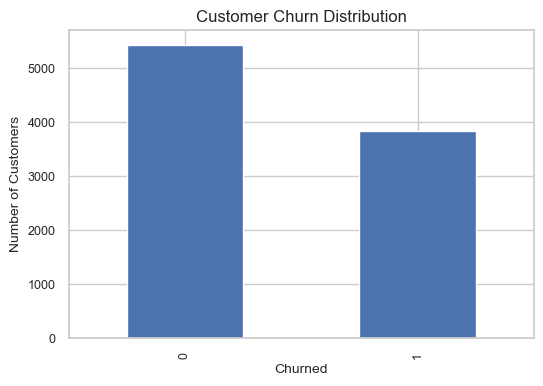

In [19]:
df['churned'].value_counts().plot(kind='bar')
plt.xlabel("Churned")
plt.ylabel("Number of Customers")
plt.title("Customer Churn Distribution")
plt.show()

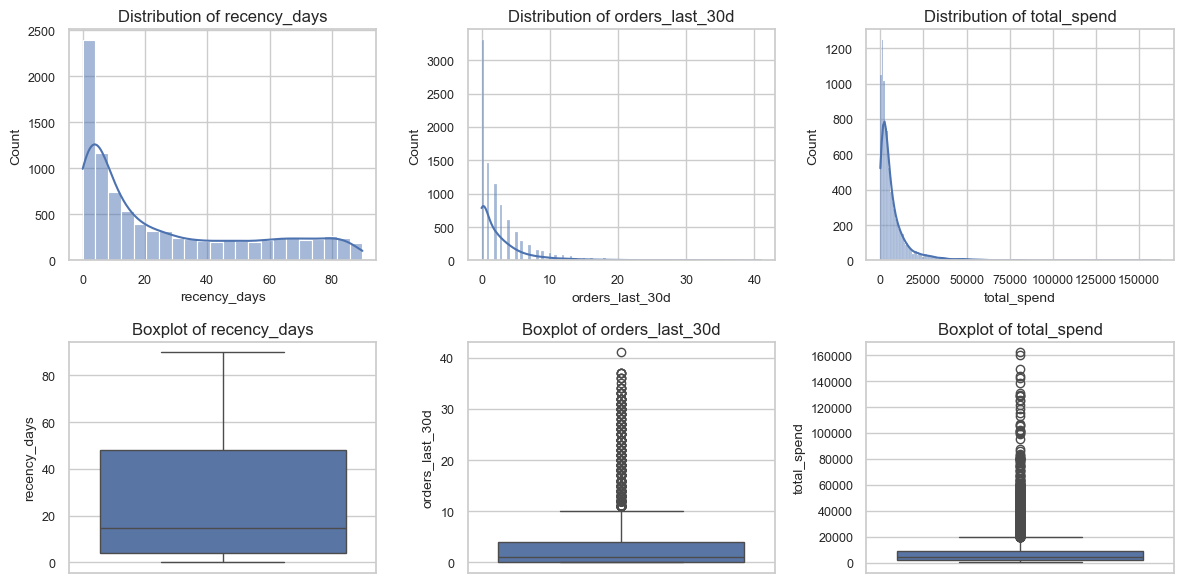

In [17]:
cols = ['recency_days', 'orders_last_30d', 'total_spend']

plt.figure(figsize=(12, 6))
for index,column in enumerate(cols):

    #Distributionplot
    plt.subplot(2,3,index+1)
    sns.histplot(df[column],
                kde=True)
    plt.title(f'Distribution of {column}')

    #Boxplot
    plt.subplot(2,3,index+4)
    sns.boxplot(df[column])
    plt.title(f'Boxplot of {column}')

plt.tight_layout()
plt.show()


### Observations

- `recency_days` is right-skewed, with many customers having relatively recent orders.
- `orders_last_30d` is strongly right-skewed, with most customers placing fewer recent orders.
- `total_spend` is heavily right-skewed, with a small number of high-spending customers.
- `orders_last_30d` and `total_spend` contain substantial upper-end outliers, representing highly active or high-spending customers.

# Bivariate Analysis

### 1. Categorical Column

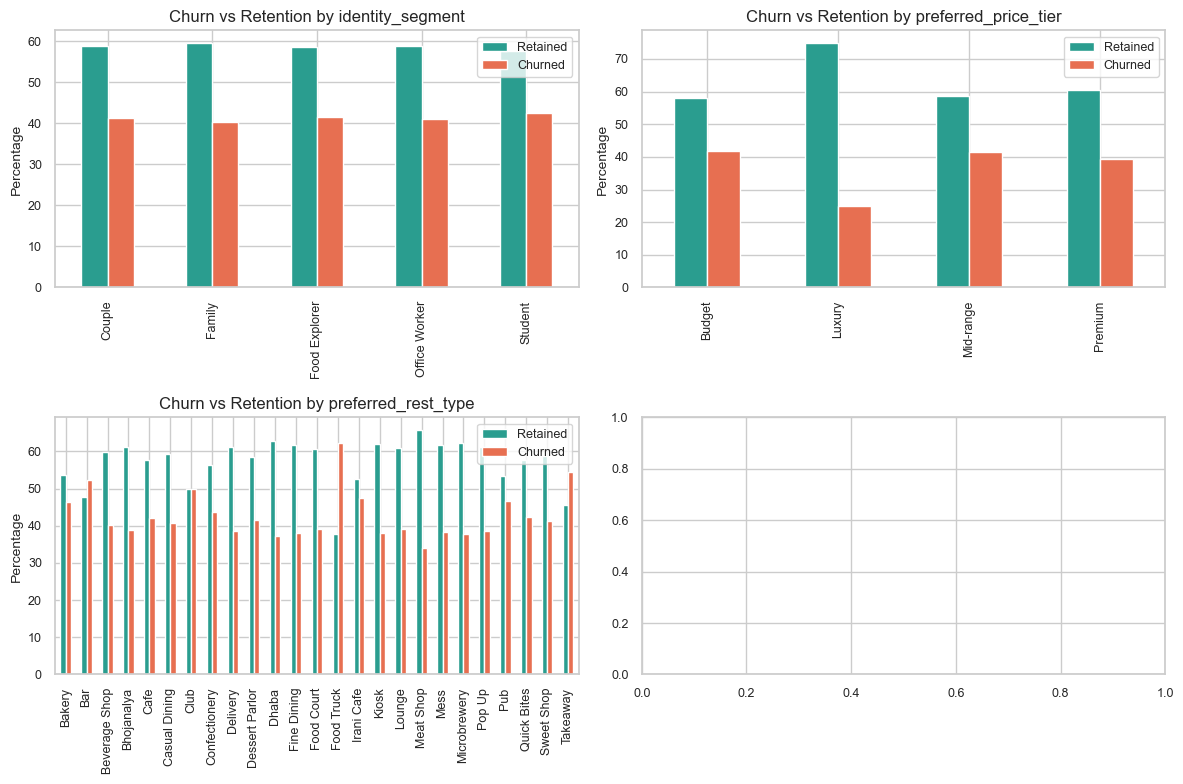

In [18]:
categorical_cols = [
    "identity_segment",
    "preferred_price_tier",
    "preferred_rest_type"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, column in zip(axes.flat, categorical_cols):

    churn_rate = df.groupby(column)['churned'].mean()*100
    retention_rate = 100 - churn_rate

    rates = pd.DataFrame({
        'Retained': retention_rate,
        'Churned': churn_rate
    })

    rates.plot(
        kind="bar",
        ax=ax,
        color=[COLORS["retained"], COLORS["churn"]]
    )

    ax.set_title(f"Churn vs Retention by {column}")
    ax.set_ylabel("Percentage")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=90)

fig.savefig(
    "../images/churn_categorical.png",
    dpi=300,
    bbox_inches="tight"
)    

plt.tight_layout()
plt.show()

### Categorical Feature Insights

- **Identity Segment:** Churn and retention rates are relatively similar across all identity segments, suggesting that identity segment has limited influence on churn in the simulated dataset.

- **Preferred Price Tier:** Churn varies noticeably across price tiers. Luxury customers show the lowest churn, while Budget, Mid-range, and Premium customers have higher churn rates.

- **Preferred Restaurant Type:** Churn rates vary across restaurant preferences, but most categories show considerable overlap between retained and churned customers. Some restaurant types show slightly higher churn, although the differences are not as pronounced as those seen for preferred price tier.

### 2. Numerical Column

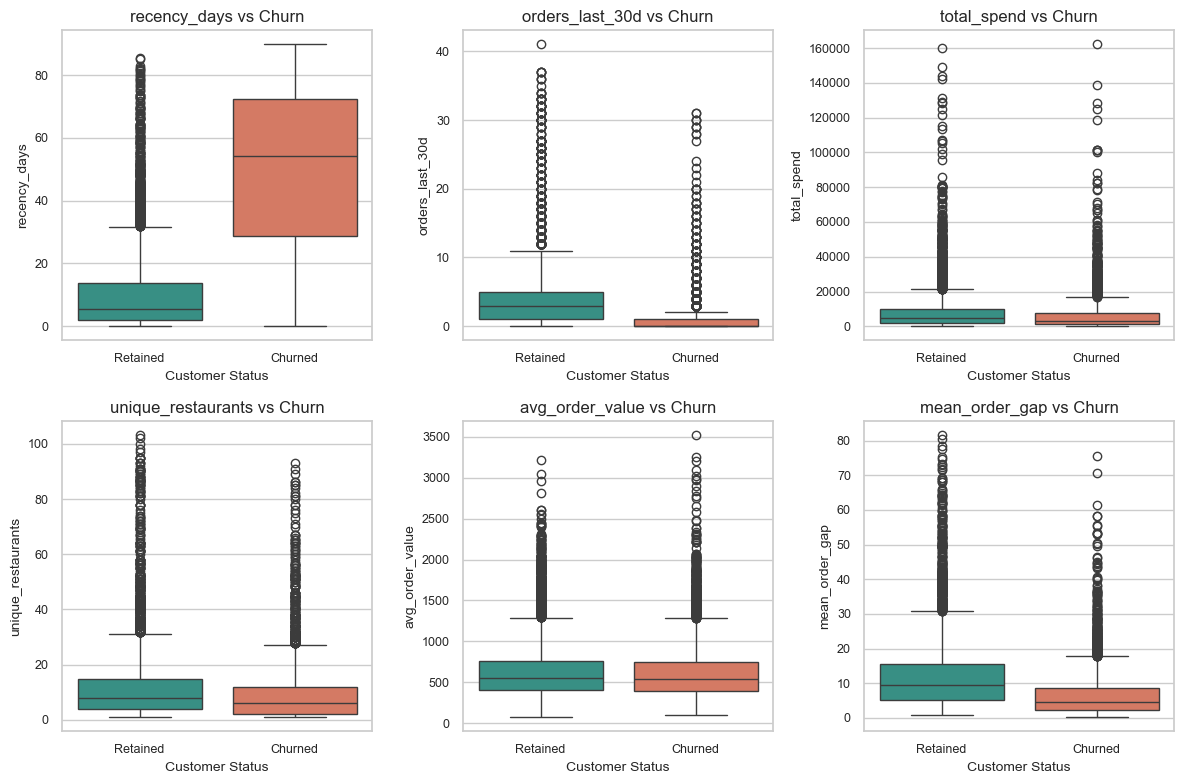

In [24]:
numeric_cols = [
    "recency_days",
    "orders_last_30d",
    "total_spend",
    "unique_restaurants",
    "avg_order_value",
    "mean_order_gap"
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax, column in zip(axes.flat, numeric_cols):

    sns.boxplot(
        data=df,
        x="churned",
        y=column,
        hue="churned",
        palette=CHURN_PALETTE,
        legend=False,
        ax=ax
    )

    ax.set_title(f"{column} vs Churn")
    ax.set_xlabel("Customer Status")
    ax.set_ylabel(column)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Retained", "Churned"])

fig.savefig(
    "../images/churn_numerical.png",
    dpi=300,
    bbox_inches="tight"
)
plt.tight_layout()
plt.show()

### Numerical Feature Insights

- **Recency vs Churn:** Churned customers have much higher recency, suggesting that reduced recent activity is strongly associated with churn.

- **Orders in Last 30 Days vs Churn:** Retained customers generally place more recent orders, while churned customers show much lower recent engagement.

- **Total Spend vs Churn:** Spending distributions are fairly similar between retained and churned customers, suggesting that total spending alone may not strongly distinguish churners.

- **Unique Restaurants vs Churn:** Retained customers generally have slightly higher restaurant diversity, suggesting that greater exploration may be associated with retention.

- **Average Order Value vs Churn:** The distributions are very similar, indicating that average order value has limited relationship with churn in this dataset.

- **Mean Order Gap vs Churn:** Retained customers show a higher average order gap than churned customers, suggesting that churn is not simply driven by longer gaps between orders.